# Sparse retrieval
Сравниваем варианты на одном фиксированном quick validation из 2452 контекстов.
Ноутбук читает готовые кеши; реализация retrieval находится в `src/`.
## 1. Setup

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.validation import load_validation
from src.pipeline import retrieve, retrieve_sources, item_locations, fuse
from src.metrics import evaluate
from src.fusion import reciprocal_rank_fusion

CORPUS, CACHE = ROOT / 'data/train.parquet', ROOT / '.cache'
queries, truth = load_validation(ROOT, 'quick')
print(f'Quick validation: {len(queries)} contexts')

Quick validation: 2452 contexts


## 2. Word TF-IDF
Используем только текст запроса. Сравним заголовок с `title + title + params`;
каждый источник возвращает top-200, а итоговую выдачу оцениваем по Recall@50.

In [2]:
word_results, rows = {}, []
for document in ['title', 'title_params']:
    spec = dict(kind='word', query='query_only', document=document)
    result = retrieve(CORPUS, queries, spec, CACHE, cache_only=True)
    word_results[document] = result
    rows.append(dict(experiment=f'word: {document}',
                     **evaluate(result.positions, truth, result.item_ids, [result.source])))
display(pd.DataFrame(rows).set_index('experiment').round(5))
word = word_results['title_params']

,R@10,R@20,R@50,candidate_recall
experiment,,,,
word: title,0.06918,0.09999,0.16129,0.29718
word: title_params,0.06866,0.09838,0.16413,0.31862


## 3. Char TF-IDF
Символьные n-граммы 3–5 помогают сопоставлять части слов, словоформы и опечатки.
Индекс строится только по заголовкам, чтобы ограничить память.

In [3]:
char = retrieve(CORPUS, queries,
                dict(kind='char', query='query_only', document='title'), CACHE, cache_only=True)
np.testing.assert_array_equal(word.item_ids, char.item_ids)
rows.append(dict(experiment='char: title',
                 **evaluate(char.positions, truth, char.item_ids, [char.source])))
display(pd.DataFrame(rows[-1:]).set_index('experiment').round(5))

,R@10,R@20,R@50,candidate_recall
experiment,,,,
char: title,0.07713,0.10653,0.17636,0.35023


## 4. Word + char: RRF
RRF складывает вклады `weight / (60 + rank)`, поэтому шкалы cosine разных источников
не нужно выравнивать. Здесь воспроизводим исходный sparse fusion с весами 1 и 1.5.

In [4]:
sources = [word.source, char.source]
positions = reciprocal_rank_fusion(sources, weights=[1., 1.5])
rows.append(dict(experiment='RRF: word + char',
                 **evaluate(positions, truth, word.item_ids, sources)))
display(pd.DataFrame(rows[-1:]).set_index('experiment').round(5))

,R@10,R@20,R@50,candidate_recall
experiment,,,,
RRF: word + char,0.07372,0.10812,0.18428,0.42383


## 5. Soft location
Бонус 0.01 повышает позиции объявлений из локации запроса внутри найденного union.
Объявления из других локаций остаются кандидатами: жесткого фильтра нет.

In [5]:
locations = item_locations(CORPUS, word.item_ids)
positions = reciprocal_rank_fusion(
    sources, weights=[1., 1.5], item_locations=locations,
    query_locations=queries.search_location_id.astype(str).to_numpy(), location_weight=.01)
rows.append(dict(experiment='RRF + location 0.01',
                 **evaluate(positions, truth, word.item_ids, sources)))
display(pd.DataFrame(rows[-2:]).set_index('experiment').round(5))

,R@10,R@20,R@50,candidate_recall
experiment,,,,
RRF: word + char,0.07372,0.10812,0.18428,0.42383
RRF + location 0.01,0.14179,0.19396,0.29104,0.42383


## 6. Вывод
Сравним качество top-50 и покрытие union до fusion. Location меняет порядок,
но не расширяет набор найденных кандидатов; этот предел дальше повышаем с помощью E5.
Все строки ниже относятся только к quick, а не к полному validation или benchmark.

,R@10,R@20,R@50,candidate_recall
experiment,,,,
word: title,0.06918,0.09999,0.16129,0.29718
word: title_params,0.06866,0.09838,0.16413,0.31862
char: title,0.07713,0.10653,0.17636,0.35023
RRF: word + char,0.07372,0.10812,0.18428,0.42383
RRF + location 0.01,0.14179,0.19396,0.29104,0.42383


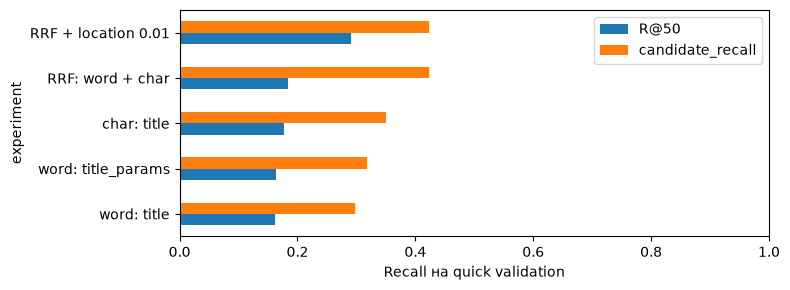

In [6]:
summary = pd.DataFrame(rows).set_index('experiment')
display(summary.round(5))
summary[['R@50', 'candidate_recall']].plot.barh(figsize=(8, 3), xlim=(0, 1))
plt.xlabel('Recall на quick validation'); plt.tight_layout(); plt.show()

Время ниже измеряет текущую загрузку кешей, а не первоначальное построение индексов.
`index_MiB` — размер sparse-массивов, не полный RSS процесса.

In [7]:
diagnostics = {**word_results, 'char': char}
display(pd.DataFrame([
    dict(source=name, index_MiB=result.index_mib, load_index_s=result.build_or_load_s,
         load_candidates_s=result.search_or_load_s, cache_hit=result.cache_hit)
    for name, result in diagnostics.items()
]).set_index('source').round(3))

,index_MiB,load_index_s,load_candidates_s,cache_hit
source,,,,
title,17.741,2.658,0.035,True
title_params,412.862,4.293,0.047,True
char,185.269,3.299,0.034,True
